In [1]:
%pip install pandas pyarrow ydata-profiling scikit-learn ipywidgets seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import methods

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
train_df = pd.read_parquet("train.parquet", engine="pyarrow")
test_df = pd.read_parquet("test.parquet", engine="pyarrow")
train_df["__is_train"] = 1
test_df["__is_train"] = 0
test_df["qty"] = np.nan
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Разделяем на train и val
max_date = train_df["dt"].max()
val_start = max_date - pd.Timedelta(days=45)
val_end = test_df["dt"].min()
full_df["__is_val"] = (
    (full_df["dt"] >= val_start)
    & (full_df["dt"] < val_end)
    & (full_df["__is_train"] == 1)
).astype(int)

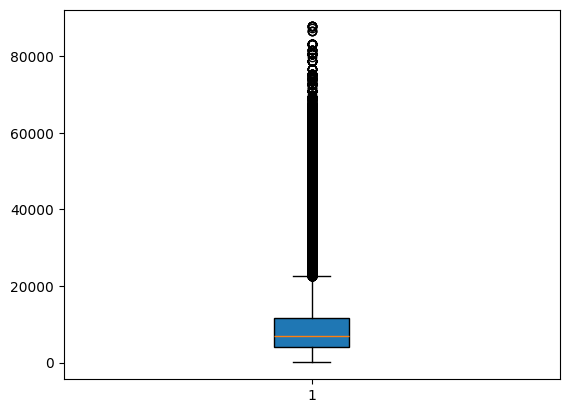

In [5]:
plt.boxplot(full_df["price"], vert=True, patch_artist=True)
plt.show()

In [6]:
full_df["log_price"] = np.log1p(full_df["price"])

In [7]:
full_df["price_cluster"] = KMeans(
    n_clusters=5, random_state=0, n_init="auto"
).fit_predict(full_df[["log_price"]])

In [8]:
full_df["price_cluster"] = full_df["price_cluster"].astype("category")
full_df["price_cluster"].describe()

count     322504
unique         5
top            3
freq       90288
Name: price_cluster, dtype: int64

In [9]:
full_df = full_df.sort_values(["dt"])

<Axes: >

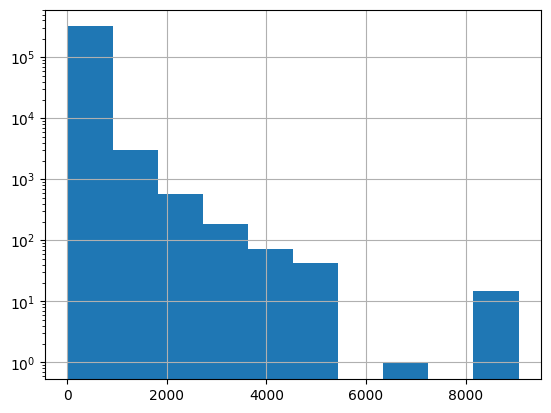

In [10]:
full_df["prev_leftovers"].hist(log=True)

In [11]:
full_df["log_prev_leftovers"] = np.log1p(full_df["prev_leftovers"])

<Axes: >

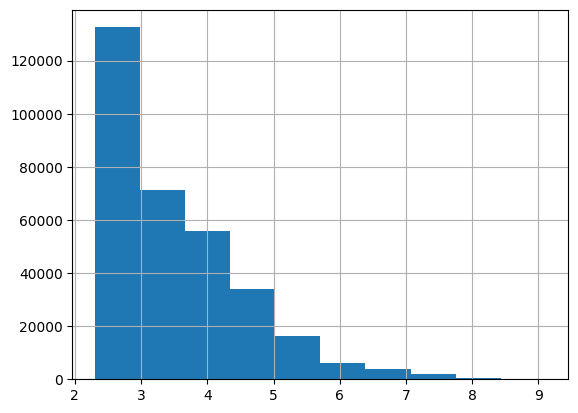

In [12]:
full_df["log_prev_leftovers"].hist()

In [13]:
# Добавляем признак is_rus_holiday
full_df = methods.add_russian_calendar_features(full_df)

# Добавляем признаки для дат
full_df = methods.add_date_features(full_df)

# Добавляем лаговые признаки по продуктам
full_df = methods.add_lag_features(full_df)

# Добавляем глобальные лаги продаж
full_df = methods.add_global_lags(full_df)

# Добавляем признаки динамики продаж
full_df = methods.add_product_activity_features(full_df)

# Добавляем складские признаки
full_df = methods.add_leftover_change_features(full_df)

# Добавляем признаки сезонности
full_df = methods.add_seasonality_flags(full_df)

# Добавляем признаки для промо
full_df = methods.add_promo_features(full_df)

# Добавляем признаки цены
full_df = methods.add_price_features(full_df)

d:\Projects\hackathon_rythm_of_sales\methods.py:273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [14]:
# mask = full_df['__is_train'] != 0

# full_df = pd.concat([
#     full_df[mask].dropna(),
#     full_df[~mask]
# ]).sort_index()

In [15]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322504 entries, 0 to 322503
Data columns (total 64 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   nm_id                       322504 non-null  object        
 1   dt                          322504 non-null  datetime64[ns]
 2   qty                         309648 non-null  float64       
 3   price                       322504 non-null  int64         
 4   is_promo                    322504 non-null  int64         
 5   prev_leftovers              322504 non-null  int64         
 6   __is_train                  322504 non-null  int64         
 7   __is_val                    322504 non-null  int64         
 8   log_price                   322504 non-null  float64       
 9   price_cluster               322504 non-null  category      
 10  log_prev_leftovers          322504 non-null  float64       
 11  is_preholiday               322504 non-

In [16]:
full_df["dt_num"] = (full_df["dt"] - full_df["dt"].min()).dt.days
full_df["nm_id"] = full_df["nm_id"].astype("category")
full_df["day_of_week"] = full_df["day_of_week"].astype("category")
full_df["week_of_year"] = full_df["week_of_year"].astype("category")


In [17]:
# ====================== SIN/COS ПРЕОБРАЗОВАНИЯ ======================
full_df = full_df.copy()  # или train_df + test_df, если работаешь раздельно

# 1. День месяца (1-31)
full_df["day_sin"] = np.sin(2 * np.pi * full_df["day"] / 31)
full_df["day_cos"] = np.cos(2 * np.pi * full_df["day"] / 31)

# 2. Месяц (1-12)
full_df["month_sin"] = np.sin(2 * np.pi * full_df["month"] / 12)
full_df["month_cos"] = np.cos(2 * np.pi * full_df["month"] / 12)

# 3. Неделя года (1-53)
full_df["week_sin"] = np.sin(
    2 * np.pi * full_df["week_of_year"].astype(int) / 53
)
full_df["week_cos"] = np.cos(
    2 * np.pi * full_df["week_of_year"].astype(int) / 53
)

# 4. День года (самый важный циклический признак!)
full_df["dayofyear"] = full_df["dt"].dt.dayofyear
full_df["dayofyear_sin"] = np.sin(2 * np.pi * full_df["dayofyear"] / 365.25)
full_df["dayofyear_cos"] = np.cos(2 * np.pi * full_df["dayofyear"] / 365.25)

In [18]:
feature_cols = [
    # Базовые признаки товара
    "nm_id",
    "log_price",  # или "log_price"
    "is_promo",
    "log_prev_leftovers",
    "price_cluster",
    # Временные признаки
    "day_of_week",
    "month",
    "week_of_year",
    "is_weeked",
    "is_non_working_day_rus",
    "is_preholiday",
    # Лаги продаж (самые важные)
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    # Скользящие средние
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    # Волатильность
    "rolling_std_3",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_30",
    # Минимумы/максимумы
    "rolling_max_7",
    "rolling_max_14",
    "rolling_min_7",
    "rolling_min_14",
    # EWMA
    "ewm_alpha_0.3",
    # Признак дня недели
    "same_day_last_week",
    # Складские признаки
    "days_since_leftover_change",
    "leftovers_changed",
    "leftovers_changed_lag",
    # Глобальные тренды
    "global_sales",
    "global_lag_1",
    "global_lag_7",
    "global_lag_14",
    # Признаки продаж
    "was_sale",
    "days_since_last_sale",
    "sales_last_30",
    "sale_days_last_30",
    # Признаки сезонности
    "high_season",
    "cold_season",
    # Признаки промо
    "promo_uplift_ratio",
    "promo_uplift",
    "promo_uplift_diff",
    # Признаки дат
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "dayofyear",
    "dayofyear_sin",
    "dayofyear_cos",
]

cat_cols = [
    "nm_id",
    "price_cluster",
    "day_of_week",
    "month",
    "week_of_year",
]

In [19]:
clf_features = [
    # Базовые признаки товара
    "nm_id",
    "log_price",  # или "log_price"
    "is_promo",
    "log_prev_leftovers",
    "price_cluster",
    # Временные признаки
    "day_of_week",
    "month",
    "week_of_year",
    "is_weeked",
    "is_non_working_day_rus",
    "is_preholiday",
    # Лаги продаж (самые важные)
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    # Волатильность
    "rolling_std_3",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_30",
    # Минимумы/максимумы
    "rolling_max_7",
    "rolling_max_14",
    "rolling_min_7",
    "rolling_min_14",
    # EWMA
    "ewm_alpha_0.3",
    # Признак дня недели
    "same_day_last_week",
    # Складские признаки
    "days_since_leftover_change",
    "leftovers_changed",
    "leftovers_changed_lag",
    # Глобальные тренды
    "global_sales",
    "global_lag_1",
    "global_lag_7",
    "global_lag_14",
    # Признаки продаж
    "was_sale",
  #  "days_since_last_sale",
    "sales_last_30",
    "sale_days_last_30",
    # Признаки сезонности
    "high_season",
    "cold_season",
    # Признаки дат
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "dayofyear",
    "dayofyear_sin",
    "dayofyear_cos",
]

clf_cat_cols = [
    "nm_id",
    "price_cluster",
    "day_of_week",
    "month",
    "week_of_year",
]

In [20]:
def wmae_metric(y_true, y_pred):
    """
    WMAE where:
        w = 1  if final prediction == 0
        w = 7  if final prediction > 0
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    weights = np.where(y_true <= 0, 1.0, 7.0)
    errors = weights * np.abs(y_true - y_pred)

    return errors.sum() / weights.sum()

In [21]:
class WMAEMetric(object):
    def get_final_error(self, error, weight):
        return error

    def is_max_optimal(self):
        return False

    def evaluate(self, approxes, target, weight):
        preds = np.clip(approxes[0], 0, None)           # ← добавлено
        targets = np.array(target, dtype=np.float64)

        sample_weights = np.where(targets == 0, 1.0, 7.0)

        if weight is not None:
            sample_weights *= np.array(weight, dtype=np.float64)

        errors = sample_weights * np.abs(targets - preds)
        error_sum = np.sum(errors)
        weight_sum = max(np.sum(sample_weights), 1e-9)

        return error_sum, weight_sum

In [22]:
# ===============================
# 1. Разделение данных
# ===============================

train_df = full_df[(full_df["__is_val"] == 0) & (full_df["qty"].notna())].copy()
val_df   = full_df[(full_df["__is_val"] == 1) & (full_df["qty"].notna())].copy()

train_df["sale"] = (train_df["qty"] > 0).astype(int)
val_df["sale"]   = (val_df["qty"] > 0).astype(int)

# ===============================
# 2. Классификатор
# ===============================

clf = CatBoostClassifier(
    iterations=2000,
    depth=6,
    learning_rate=0.04,
    l2_leaf_reg=3.0,

    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 7],

    random_seed=42,
    cat_features=clf_cat_cols,

    verbose=200,
    early_stopping_rounds=120,

    bootstrap_type="Bernoulli",
    subsample=0.8,
)

clf.fit(
    train_df[clf_features],
    train_df["sale"],
    eval_set=(val_df[clf_features], val_df["sale"]),
    use_best_model=True
)

# ===============================
# 3. Регрессор (только реальные положительные qty)
# ===============================

reg_train = train_df[train_df["qty"] > 0].copy()
reg_train["log_qty"] = np.log1p(reg_train["qty"])

reg = CatBoostRegressor(
    iterations=1200,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="MAE",
    random_seed=42,
    verbose=200,
    cat_features=cat_cols,
)

reg.fit(
    reg_train[feature_cols],
    reg_train["log_qty"]
)

# ===============================
# 4. Подбор оптимального threshold по WMAE
# ===============================

val_proba = clf.predict_proba(val_df[clf_features])[:, 1]
val_reg_pred = np.expm1(reg.predict(val_df[feature_cols]))
val_reg_pred = np.clip(val_reg_pred, 0, None)

best_score = np.inf
best_threshold = 0.5

thresholds = np.linspace(0.01, 0.99, 50)

for t in thresholds:
    sale_mask = (val_proba >= t).astype(int)
    final_pred = sale_mask * val_reg_pred

    score = wmae_metric(val_df["qty"], final_pred)

    if score < best_score:
        best_score = score
        best_threshold = t

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best WMAE: {best_score:.6f}")

0:	test: 0.8657405	best: 0.8657405 (0)	total: 332ms	remaining: 11m 2s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.8909124809
bestIteration = 30

Shrink model to first 31 iterations.
0:	learn: 0.3220769	total: 58ms	remaining: 1m 9s
200:	learn: 0.2370668	total: 9.61s	remaining: 47.8s
400:	learn: 0.2298245	total: 18.7s	remaining: 37.3s
600:	learn: 0.2256246	total: 27.6s	remaining: 27.5s
800:	learn: 0.2235043	total: 36.9s	remaining: 18.4s
1000:	learn: 0.2211802	total: 46.3s	remaining: 9.2s
1199:	learn: 0.2195341	total: 55.6s	remaining: 0us
Best threshold: 0.5700
Best WMAE: 2.375085


In [164]:
# ===============================
# 1. Берём тест из full_df
# ===============================

test_df = full_df[full_df["__is_train"] == 0].copy()

X_test = test_df[feature_cols]
X_test_clf = test_df[clf_features]

# ===============================
# 2. Предсказания
# ===============================

test_proba = clf.predict_proba(X_test_clf)[:, 1]
test_reg_pred = np.expm1(reg.predict(X_test))
test_reg_pred = np.clip(test_reg_pred, 0, None)

# используем найденный лучший threshold
sale_mask = (test_proba >= 0.565).astype(int)
test_df["qty_pred"] = sale_mask * np.round(np.maximum(test_reg_pred, 3))


# ===============================
# 3. Submission
# ===============================

submission = (
    test_df[["nm_id", "dt", "qty_pred"]]
    .rename(columns={"qty_pred": "qty"})
)

submission.to_csv("submission.csv", index=False)


In [165]:
boost_factor = 1 + 0.3 * (test_proba - 0.565).clip(0, 1)  # от 1.0 до ~1.18

submission["qty"] = np.round(submission["qty"] * boost_factor)


submission.to_csv("submission.csv", index=False)


In [166]:
df1 = pd.read_csv('submission.csv')
df2 = pd.read_csv('submission_1.94.csv')

# Сравнение значений
diff = df1.compare(df2)
print(diff)

Empty DataFrame
Columns: []
Index: []


In [24]:
val_proba    = clf.predict_proba(val_df[clf_features])[:, 1]
val_reg_pred = np.expm1(reg.predict(val_df[feature_cols]))
val_reg_pred = np.clip(val_reg_pred, 0, None)

best_score    = np.inf
best_threshold = 0.55

# Более плотный поиск в зоне, где сейчас работает лучше всего
thresholds = np.linspace(0.35, 0.70, 141)   # шаг ~0.0025

for t in thresholds:
    sale_mask   = (val_proba >= t).astype(int)
    final_pred  = sale_mask * val_reg_pred
    score       = wmae_metric(val_df["qty"], final_pred)
    
    if score < best_score:
        best_score    = score
        best_threshold = t

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best WMAE: {best_score:.6f}")

Best threshold: 0.5650
Best WMAE: 2.373896


In [25]:
val_proba     = clf.predict_proba(val_df[clf_features])[:, 1]
val_reg_pred  = np.expm1(reg.predict(val_df[feature_cols]))   # или как у вас

sale_mask     = (val_proba >= 0.495).astype(int)

for clip_val in [2.2, 2.4, 3.0, 3.2, 3.3, 3.4]:
    pred = sale_mask * np.round(np.maximum(val_reg_pred, clip_val))
    score = wmae_metric(val_df["qty"], pred)  # или на вашей валидации
    print(f"clip {clip_val} → {score:.6f}")

clip 2.2 → 2.362691
clip 2.4 → 2.362691
clip 3.0 → 2.362691
clip 3.2 → 2.362691
clip 3.3 → 2.362691
clip 3.4 → 2.362691


wMAE on validation: 2.361669864455035
Mean error on positive qty: 3.8739780658025924
Mean error on zero qty: 0.5634251261728144


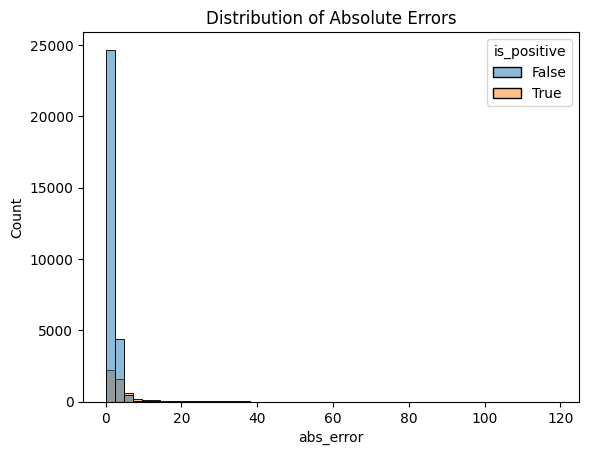

False Negatives count: 1046 (these cost x7 in wMAE)


In [26]:
sale_mask = (val_proba >= best_threshold).astype(int)
val_pred = sale_mask * np.round(np.maximum(val_reg_pred, 3))

wmae_score = wmae_metric(val_df["qty"], val_pred)
print(f"wMAE on validation: {wmae_score}")

# Разбить ошибки по типам
errors_df = pd.DataFrame(
    {
        "true_qty": val_df["qty"],
        "pred_qty": val_pred,
        "abs_error": np.abs(val_df["qty"] - val_pred),
        "is_positive": val_df["qty"] > 0,
    }
)
print(
    "Mean error on positive qty:",
    errors_df[errors_df["is_positive"]]["abs_error"].mean(),
)
print(
    "Mean error on zero qty:",
    errors_df[~errors_df["is_positive"]]["abs_error"].mean(),
)

# Визуализация: распределение ошибок
sns.histplot(data=errors_df, x="abs_error", bins=50, hue="is_positive")
plt.title("Distribution of Absolute Errors")
plt.show()

# Проверить false negatives (предсказали 0, а было >0)
fn_mask = (val_pred == 0) & (val_df["qty"] > 0)
print(f"False Negatives count: {fn_mask.sum()} (these cost x7 in wMAE)")

Classifier Feature Importance:
                        feature  importance
36           sale_days_last_30   25.555894
37                 high_season   14.618635
0                        nm_id   13.703752
27  days_since_leftover_change    8.923685
4                price_cluster    7.366868
25               ewm_alpha_0.3    5.364117
22              rolling_max_14    3.580830
20              rolling_std_30    3.548342
21               rolling_max_7    2.490481
19              rolling_std_14    1.954635
1                    log_price    1.572146
35               sales_last_30    1.547947
14                       lag_7    1.388844
18               rolling_std_7    1.156191
30                global_sales    1.093405
17               rolling_std_3    0.987109
6                        month    0.944077
13                       lag_3    0.860901
38                 cold_season    0.641572
28           leftovers_changed    0.481564
2                     is_promo    0.362879
16                    

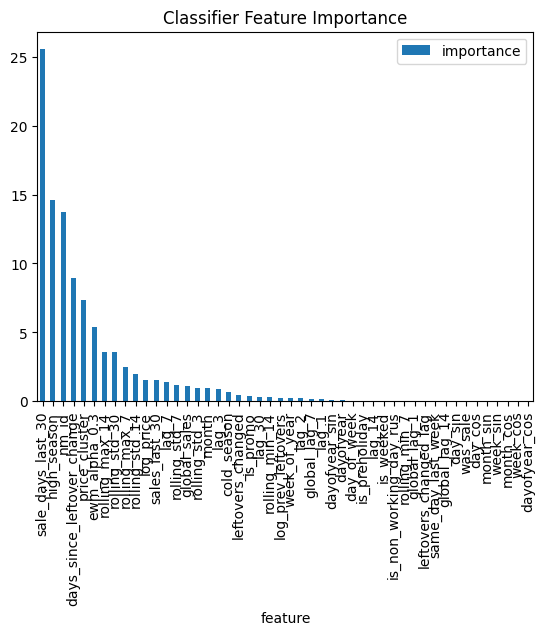

In [27]:
# Для классификатора
clf_importance = pd.DataFrame(
    {"feature": clf_features, "importance": clf.get_feature_importance()}
).sort_values("importance", ascending=False)
print("Classifier Feature Importance:\n", clf_importance)

# Для регрессора
reg_importance = pd.DataFrame(
    {"feature": feature_cols, "importance": reg.get_feature_importance()}
).sort_values("importance", ascending=False)
print("Regressor Feature Importance:\n", reg_importance)

# Визуализация
clf_importance.plot(kind="bar", x="feature", y="importance")
plt.title("Classifier Feature Importance")
plt.show()

In [28]:
inter = reg.get_feature_importance(prettified=True, type="Interaction")

inter["Feature1"] = inter["First Feature Index"].apply(
    lambda x: feature_cols[int(x)]
)
inter["Feature2"] = inter["Second Feature Index"].apply(
    lambda x: feature_cols[int(x)]
)

print(inter[["Feature1", "Feature2", "Interaction"]].head(20))

              Feature1           Feature2  Interaction
0      rolling_mean_30     rolling_std_14     1.355944
1      rolling_mean_14      ewm_alpha_0.3     1.312090
2      rolling_mean_14    rolling_mean_30     1.169884
3       rolling_std_30  promo_uplift_diff     0.911910
4      rolling_mean_30      ewm_alpha_0.3     0.893756
5      rolling_mean_30       promo_uplift     0.843700
6      rolling_mean_14     rolling_std_30     0.827820
7      rolling_mean_30  promo_uplift_diff     0.805678
8      rolling_mean_30     rolling_std_30     0.740957
9            log_price  promo_uplift_diff     0.725745
10           log_price    rolling_mean_30     0.704337
11      rolling_mean_7    rolling_mean_14     0.671671
12     rolling_mean_14  promo_uplift_diff     0.663678
13      rolling_std_30      ewm_alpha_0.3     0.649822
14     rolling_mean_14     rolling_std_14     0.648296
15  log_prev_leftovers     rolling_std_30     0.633391
16            is_promo  promo_uplift_diff     0.575018
17  log_pr

In [ ]:
for t in [0.28, 0.32, 0.36, 0.40]:
    for minv in [3.4, 3.6, 3.8, 4.0]:
        mask = (val_proba >= t).astype(int)
        pred = mask * np.round(np.maximum(val_reg_pred, minv))
        sc = wmae_metric(val_df["qty"], pred)
        print(f"t = {t:.2f} | min = {minv:.1f} → wMAE {sc:.6f}")

t = 0.28 | min = 3.4 → wMAE 2.683667
t = 0.28 | min = 3.6 → wMAE 3.067695
t = 0.28 | min = 3.8 → wMAE 3.067695
t = 0.28 | min = 4.0 → wMAE 3.067695
t = 0.32 | min = 3.4 → wMAE 2.596351
t = 0.32 | min = 3.6 → wMAE 2.937411
t = 0.32 | min = 3.8 → wMAE 2.937411
t = 0.32 | min = 4.0 → wMAE 2.937411
t = 0.36 | min = 3.4 → wMAE 2.507628
t = 0.36 | min = 3.6 → wMAE 2.801572
t = 0.36 | min = 3.8 → wMAE 2.801572
t = 0.36 | min = 4.0 → wMAE 2.801572
t = 0.40 | min = 3.4 → wMAE 2.447422
t = 0.40 | min = 3.6 → wMAE 2.703256
t = 0.40 | min = 3.8 → wMAE 2.703256
t = 0.40 | min = 4.0 → wMAE 2.703256


In [30]:
train_df[train_df["qty"]>0]["qty"].describe()

count    34977.000000
mean         6.274466
std         12.006873
min          3.000000
25%          3.000000
50%          3.000000
75%          6.000000
max        291.000000
Name: qty, dtype: float64

In [42]:
df1 = pd.read_csv('submission.csv')
df2 = pd.read_csv('submission_1.97.csv')

# Сравнение значений
diff = df1.compare(df2)
print(diff)

Empty DataFrame
Columns: []
Index: []


<Axes: >

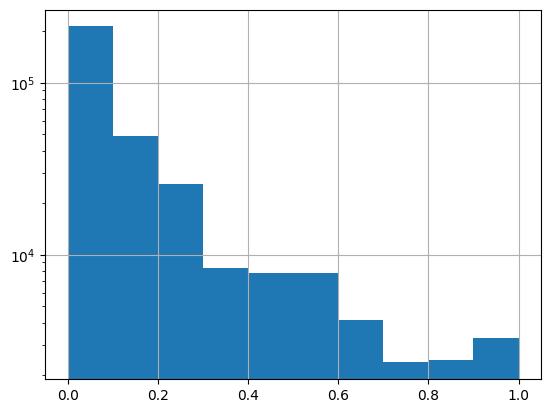

In [32]:
full_df["sale_days_last_30"].hist(log=True)

In [33]:
full_df.describe()

,dt,qty,price,is_promo,prev_leftovers,__is_train,__is_val,log_price,log_prev_leftovers,day,month,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_30,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,rolling_max_7,rolling_min_7,rolling_max_14,rolling_min_14,ewm_alpha_0.3,same_day_last_week,trend_7,global_sales,global_lag_1,global_lag_7,global_lag_14,was_sale,sales_last_30,sale_days_last_30,days_since_last_sale,leftovers_changed,leftovers_changed_lag,days_since_leftover_change,high_season,cold_season,mean_qty_promo,mean_qty_no_promo,promo_uplift_ratio,promo_uplift,promo_uplift_diff,lag_price_1,rolling_mean_price_7,price_diff_1,price_ratio_7,expanding_mean_price,price_change_pct,dt_num,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,dayofyear,dayofyear_sin,dayofyear_cos
count,322504,309648.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,307852.000000,306100.000000,304387.000000,297860.000000,287129.000000,271082.000000,251689.000000,309729.000000,306089.000000,313442.000000,309771.000000,319737.000000,316058.000000,319737.000000,316928.000000,313442.000000,313442.000000,319737.000000,319737.000000,3.197370e+05,297860.000000,292357.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,319759.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000,315516.000000,315516.000000,3.225040e+05,322504.000000,322504.000000,319759.000000,319759.000000,319759.000000,319759.000000,319759.000000,319759.000000,322504.000000,322504.000000,322504.000000,322504.000000,3.225040e+05,322504.000000,322504.000000,322504.000000,322504.000000,322504.000000
mean,2024-12-29 17:43:25.541636352,0.845906,9289.972813,0.503560,73.903437,0.960137,0.107093,8.869260,3.489576,15.453052,6.940407,0.822054,0.817566,0.813671,0.802827,0.790234,0.781015,0.767197,0.820777,0.695907,0.819747,0.857204,0.819316,0.962758,0.823958,1.067919,2.332393,0.188092,3.127952,0.142880,8.220933e-01,0.802827,0.001080,677.287627,677.287627,677.287627,677.287627,0.759191,20.892500,0.113151,28.206239,0.176283,0.174482,21.090628,0.110516,0.041159,1.066867,0.680053,1.731467e+05,0.148204,0.378432,9296.961299,9327.001251,-11.534105,0.997154,9535.184913,0.962406,178.738490,0.029763,-0.042270,-0.118253,-2.027513e-03,-0.106598,-0.047905,195.871022,-0.104374,-0.025047
min,2024-07-04 00:00:00,0.000000,48.000000,0.000000,9.000000,0.000000,0.000000,3.891820,2.302585,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-25.392857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-3.091042,-23.935897,48.000000,1017.000000,-72474.000000,0.024878,1017.000000,0.016410,0.000000,-0.998717,-0.994869,-1.000000,-1.000000e+00,-0.999561,-0.998244,1.000000,-0.999999,-0.999979
25%,2024-09-27 00:00:00,0.000000,4200.000000,0.000000,12.000000,1.000000,0.000000,8.343078,2.564949,8.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.297377e-22,0.000000,0.000000,519.000000,519.000000,519.000000,519.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.069767,0.010345,6.578936e-01,-0.003834,-0.004701,4206.000000,4259.571429,0.000000,0.970507,4789.590455,0.822044,85.000000,-0.651372,-0.758758,-0.866025,-8.660254e-01,-0.737833,-0.794854,113.000000,-0.739392,-0.787260
50%,2024-12-19 00:00:00,0.000000,6966.000000,1.000000,24.000000,1.000000,0.000000,8.848940,3.218876,15.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.